In [1]:
import mne

fname_main = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
fname_rest = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/resting.fif"

raw_main = mne.io.read_raw_fif(fname_main, preload=True)
sfreq = raw_main.info['sfreq']

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_11032/958063.py:6: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_main = mne.io.read_raw_fif(fname_main, preload=True)


Reading 0 ... 2542999  =      0.000 ...  2542.999 secs...


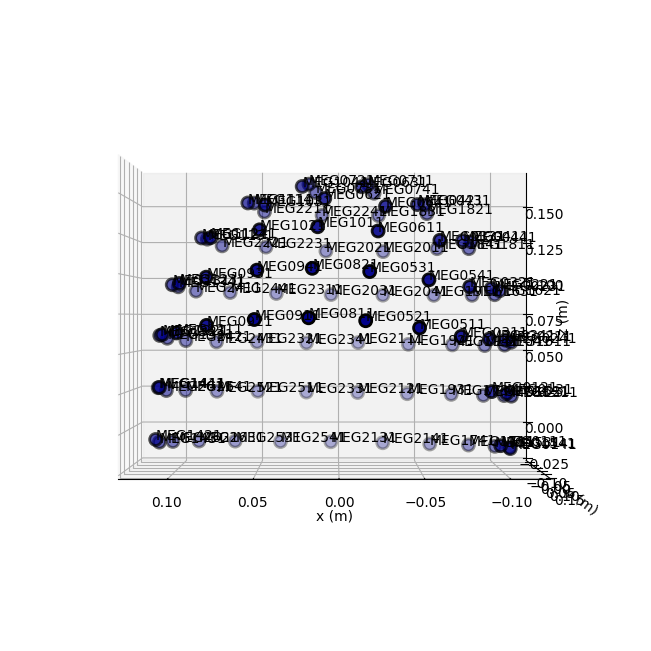

In [3]:
info = raw_main.info
fig = mne.viz.plot_sensors(
    info,
    kind='3d',
    show_names=True,
    title='Sensor Positions with Names'
)

In [5]:
import mne
import numpy as np

# 1. Load your existing data
fname_main = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname_main, preload=False)

# 2. Inspect channel names to guess the correct cap type
print(raw.ch_names)
# Look for patterns like Fz, Cz, Pz, etc., or specific naming like 'Fp1', 'O1'

# 3. Assign a template montage (try the most common ones)
# For a standard 10-20 EEG system:
montage = mne.channels.make_standard_montage('standard_1020')

# Alternative options if your cap has more channels:
# montage = mne.channels.make_standard_montage('standard_1005')  # For 10-05 system
# montage = mne.channels.make_standard_montage('biosemi64')      # For BioSemi caps

raw.set_montage(montage, match_case=False)  # match_case=False helps with naming variations
print("Montage assigned successfully.")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_11032/1596276470.py:6: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname_main, preload=False)


In [14]:
ch_positions = {}
meg_channels = mne.pick_types(raw.info, meg=True)
meg_ch_names = [raw.ch_names[idx] for idx in meg_channels]

for idx in meg_channels:
    ch_info = raw.info['chs'][idx]
    ch_name = ch_info['ch_name']
    # Get the 3D location (in meters, head coordinate frame)
    loc = ch_info['loc'][:3]  # First 3 values are the channel position
    ch_positions[ch_name] = loc

print(f"\nFound positions for {len(ch_positions)} MEG channels")


Found positions for 306 MEG channels


In [15]:
import mne
import numpy as np
from collections import defaultdict

fname_main = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname_main, preload=False)

# Step 1: Check what MEG channels you have
meg_channels = mne.pick_types(raw.info, meg=True)
meg_ch_names = [raw.ch_names[idx] for idx in meg_channels]

print(f"Total MEG channels: {len(meg_ch_names)}")
print(f"First 10 MEG channels: {meg_ch_names[:10]}")

# Step 2: Get the channel positions (they should already be in the file)
# For MEG, positions are stored in raw.info['chs']
ch_positions = {}
for idx in meg_channels:
    ch_info = raw.info['chs'][idx]
    ch_name = ch_info['ch_name']
    # Get the 3D location (in meters, head coordinate frame)
    loc = ch_info['loc'][:3]  # First 3 values are the channel position
    ch_positions[ch_name] = loc

print(f"\nFound positions for {len(ch_positions)} MEG channels")

# Step 3: Define brain regions based on spatial coordinates
def assign_brain_region_by_position(pos_3d):
    """
    Assign brain region based on 3D coordinates in head coordinate frame.
    Head coordinates: x = left-right, y = front-back, z = up-down
    """
    x, y, z = pos_3d  # positions in meters

    # Convert to cm for easier interpretation
    x_cm, y_cm, z_cm = x*100, y*100, z*100

    # Define regions based on position
    # Left hemisphere (negative x)
    if x < 0:
        hemisphere = "Left"
    # Right hemisphere (positive x)
    elif x > 0:
        hemisphere = "Right"
    else:
        hemisphere = "Midline"

    # Determine lobe based on y (anterior-posterior) and z (superior-inferior)
    # y: anterior = positive, posterior = negative (typically)
    # z: superior = positive, inferior = negative

    # Frontal (anterior)
    if y > 0.03:  # More than 3cm forward from center
        if z > 0.02:  # Superior
            region = "Superior Frontal"
        elif z < -0.02:  # Inferior
            region = "Inferior Frontal"
        else:
            region = "Frontal"
    # Occipital (posterior)
    elif y < -0.05:  # More than 5cm backward
        if z > 0.02:
            region = "Superior Occipital"
        else:
            region = "Occipital"
    # Temporal (lateral)
    elif abs(x) > 0.04:  # Lateral
        if y > 0:
            region = "Anterior Temporal"
        else:
            region = "Posterior Temporal"
    # Central/Parietal
    else:
        if z > 0.03:
            region = "Superior Parietal/Central"
        else:
            region = "Parietal"

    return f"{hemisphere} {region}".strip()

# Step 4: Assign regions to all MEG channels
channels_by_region = defaultdict(list)
channel_regions = {}

for ch_name, pos in ch_positions.items():
    region = assign_brain_region_by_position(pos)
    channels_by_region[region].append(ch_name)
    channel_regions[ch_name] = region

# Print results
print("\n=== MEG Channels by Brain Region ===")
for region in sorted(channels_by_region.keys()):
    channels = channels_by_region[region]
    print(f"\n{region} ({len(channels)} channels):")
    # Show first 5 channels per region to avoid clutter
    ch_display = channels[:5]
    if len(channels) > 5:
        ch_display.append(f"... and {len(channels)-5} more")
    print(f"  {', '.join(ch_display)}")

# Step 5: Get more precise anatomical labels using fsaverage template
# This gives you the actual brain region names (e.g., "precentral", "superiortemporal")
print("\n=== Getting precise anatomical labels using fsaverage template ===")

# Download fsaverage if needed
subjects_dir = mne.datasets.sample.data_path() / 'subjects'
try:
    mne.datasets.fetch_fsaverage(subjects_dir)
except:
    print("Could not fetch fsaverage automatically. Using coordinate-based mapping instead.")
    use_template = False
else:
    use_template = True

if use_template:
    # Transform channel positions to MRI space
    # First, get the trans matrix (if available)
    if raw.info.get('dev_head_t', None):
        trans = raw.info['dev_head_t']['trans']

        # Transform MEG positions to MRI coordinates
        from scipy.spatial.transform import Rotation

        # This is simplified - full transformation requires proper coregistration
        print("\nTo get precise anatomical labels, you need:")
        print("1. A trans file (head-to-MRI transformation)")
        print("2. A freesurfer subject directory with the subject's MRI")
        print("\nAlternatively, you can use the coordinate-based regions above.")
    else:
        print("\nNo head-to-device transformation found in the data.")

# Step 6: Create a mapping table you can use for analysis
import pandas as pd

# Create a DataFrame with channel info
channel_info = []
for ch_name in meg_ch_names[:10]:  # Show first 10 as example
    pos = ch_positions[ch_name]
    region = channel_regions[ch_name]
    channel_info.append({
        'Channel': ch_name,
        'X (m)': pos[0],
        'Y (m)': pos[1],
        'Z (m)': pos[2],
        'Region': region
    })

df = pd.DataFrame(channel_info)
print("\n=== Sample Channel Information ===")
print(df.to_string(index=False))

# Step 7: Visualize to verify the mapping
# This will show a 3D plot of your MEG channels
fig = mne.viz.plot_alignment(
    raw.info,
    trans=None,  # Use head coordinates
    subject='fsaverage',  # Template brain
    subjects_dir=subjects_dir if use_template else None,
    surfaces='head',
    meg='sensors',
    show_axes=True,
    dig=True
)
print("\nVisualization created - check the 3D plot to verify channel locations")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_11032/2637218014.py:6: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname_main, preload=False)
/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|█████████████████████████████████████| 1.65G/1.65G [00:00<00:00, 4.25TB/s]
Untarring contents of '/Users/roman/mne_data/MNE-sample-data-processed.tar.gz' to '/Users/roman/mne_data'


Attempting to create new mne-python configuration file:
/Users/roman/.mne/mne-python.json
Could not read the /Users/roman/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 04m10s (1576.2 MB)
16 files missing from root.txt in /Users/roman/mne_data/MNE-sample-data/subjects


100%|████████████████████████████████████████| 196M/196M [00:00<00:00, 699GB/s]


Extracting missing files
Successfully extracted 16 files
10 files missing from bem.txt in /Users/roman/mne_data/MNE-sample-data/subjects/fsaverage


100%|████████████████████████████████████████| 239M/239M [00:00<00:00, 786GB/s]


Extracting missing files
Successfully extracted 10 files

To get precise anatomical labels, you need:
1. A trans file (head-to-MRI transformation)
2. A freesurfer subject directory with the subject's MRI

Alternatively, you can use the coordinate-based regions above.

=== Sample Channel Information ===
Channel   X (m)  Y (m)   Z (m)                 Region
MEG0113 -0.1066 0.0464 -0.0604  Left Inferior Frontal
MEG0112 -0.1066 0.0464 -0.0604  Left Inferior Frontal
MEG0111 -0.1066 0.0464 -0.0604  Left Inferior Frontal
MEG0122 -0.1020 0.0631 -0.0256  Left Inferior Frontal
MEG0123 -0.1020 0.0631 -0.0256  Left Inferior Frontal
MEG0121 -0.1020 0.0631 -0.0256  Left Inferior Frontal
MEG0132 -0.1085 0.0302 -0.0266  Left Inferior Frontal
MEG0133 -0.1085 0.0302 -0.0266  Left Inferior Frontal
MEG0131 -0.1085 0.0302 -0.0266  Left Inferior Frontal
MEG0143 -0.1099 0.0131 -0.0627 Left Anterior Temporal


ValueError: A head<->mri transformation matrix (trans) is required to plot head surfaces in head coordinates, `trans=None` is not allowed

In [18]:
import mne
import pandas as pd
from collections import defaultdict

fname_main = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname_main, preload=False)

# Get MEG channels and positions
meg_channels = mne.pick_types(raw.info, meg=True)
ch_positions = {}
for idx in meg_channels:
    ch_name = raw.info['chs'][idx]['ch_name']
    pos = raw.info['chs'][idx]['loc'][:3]
    ch_positions[ch_name] = pos

# Simple region assignment based on coordinates
def get_region(x, y, z):
    # Simplified version
    if y > 0.03:  # Front
        return 'Frontal'
    elif y < -0.05:  # Back
        return 'Occipital'
    elif abs(x) > 0.04:  # Sides
        return 'Temporal'
    else:
        return 'Central/Parietal'

# Map regions
results = []
for ch, pos in ch_positions.items():
    region = get_region(pos[0], pos[1], pos[2])
    results.append({'Channel': ch, 'Region': region, 'X': pos[0], 'Y': pos[1], 'Z': pos[2]})

# Create summary
df = pd.DataFrame(results)
print("\n=== Brain Region Summary ===")
print(df['Region'].value_counts())

# Group by region
for region, group in df.groupby('Region'):
    print(f"\n{region} ({len(group)} channels):")
    print(f"  {', '.join(group['Channel'].values[:])}")
    # if len(group) > 10:
    #     print(f"  ... and {len(group)-10} more")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_11032/2464806550.py:6: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname_main, preload=False)


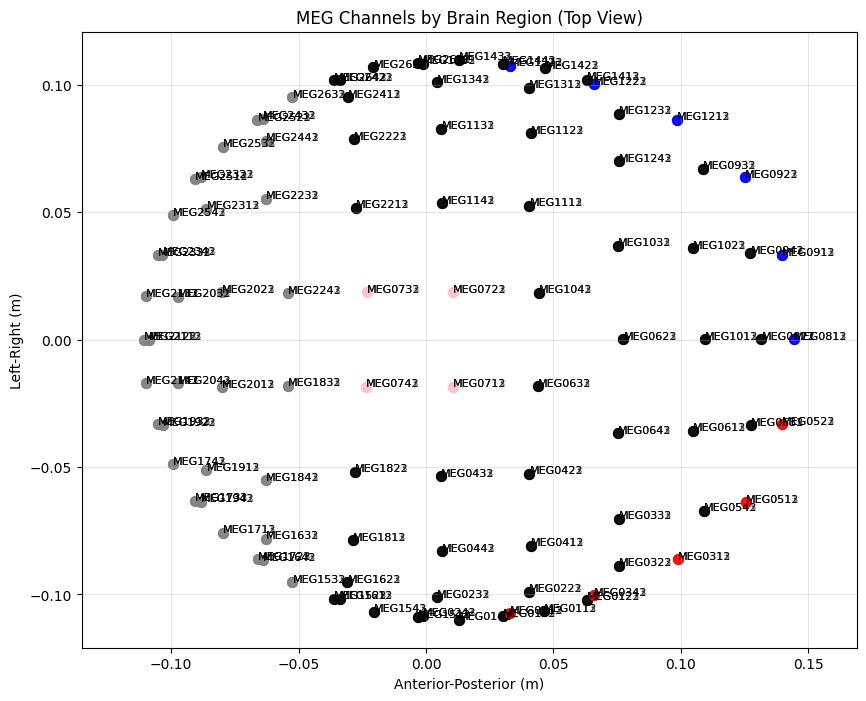

In [17]:
# Create a simple 2D top-down view
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Color mapping
region_colors = {
    'Left Frontal': 'red',
    'Right Frontal': 'blue',
    'Left Temporal': 'green',
    'Right Temporal': 'orange',
    'Left Parietal': 'purple',
    'Right Parietal': 'brown',
    'Occipital': 'gray',
    'Central': 'pink'
}

# Plot each channel
for ch_name, pos in ch_positions.items():
    region = channel_regions[ch_name]
    color = next((c for r, c in region_colors.items() if r in region), 'black')
    ax.scatter(pos[1], pos[0], c=color, s=50, alpha=0.6)  # y vs x for top view
    ax.annotate(ch_name, (pos[1], pos[0]), fontsize=8, alpha=0.7)

ax.set_xlabel('Anterior-Posterior (m)')
ax.set_ylabel('Left-Right (m)')
ax.set_title('MEG Channels by Brain Region (Top View)')
ax.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
raw.get_montage().get_positions()

{'ch_pos': OrderedDict(),
 'coord_frame': 'head',
 'nasion': array([-2.06715951e-09,  1.14046625e-01,  2.14597853e-11]),
 'lpa': array([-8.24900059e-02,  1.51032611e-09,  9.43994882e-13]),
 'rpa': array([ 8.24900059e-02, -1.51032611e-09, -9.43987943e-13]),
 'hsp': None,
 'hpi': None}

In [10]:
raw.set_montage('standard_1020')
raw.get_montage().get_positions()

{'ch_pos': OrderedDict(),
 'coord_frame': 'head',
 'nasion': array([-2.06715951e-09,  1.14046625e-01,  2.14597853e-11]),
 'lpa': array([-8.24900059e-02,  1.51032611e-09,  9.43994882e-13]),
 'rpa': array([ 8.24900059e-02, -1.51032611e-09, -9.43987943e-13]),
 'hsp': None,
 'hpi': None}

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_11032/4012417740.py:6: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname_main, preload=False)
/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_11032/4012417740.py:51: RuntimeWarning: Not setting positions of 154 grad/mag channels found in montage:
['MEG0112', 'MEG0111', 'MEG0122', 'MEG0123', 'MEG0121', 'MEG0132', 'MEG0133', 'MEG0131', 'MEG0143', 'MEG0142', 'MEG0141', 'MEG0213', 'MEG0212', 'MEG0211', 'MEG0222', 'MEG0223', 'MEG0221', 'MEG0232', 'MEG0233', 'MEG0231', 'MEG0243', 'MEG0242', 'MEG0241', 'MEG0313', 'MEG0312', 'MEG0311', 'MEG0322', 'MEG0323', 'MEG0321', 'MEG0333', 'MEG0332', 'MEG0331', 'MEG034

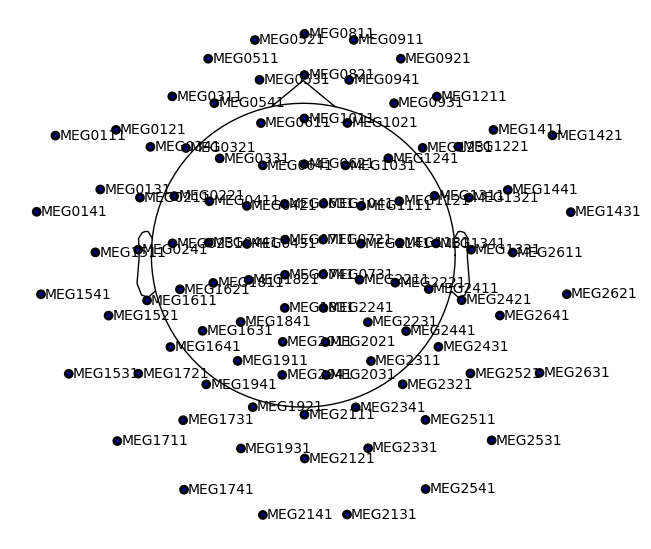

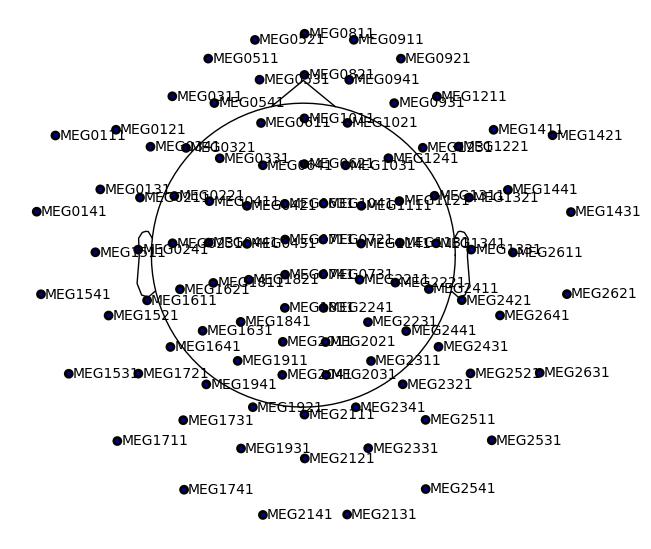

In [8]:
import mne
import numpy as np
from collections import OrderedDict

fname_main = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname_main, preload=False)

# Step 1: Check what's in your data
print("=== Data Info ===")
print(f"Channel names: {raw.ch_names[:10]}...")  # First 10 channels
print(f"Number of channels: {len(raw.ch_names)}")

# Step 2: Check if there's digitized position data in the file
if raw.info.get('dig', None):
    print(f"\nDigitization points found: {len(raw.info['dig'])}")
    # Check what types of digitized points exist
    dig_points = raw.info['dig']
    hpi_count = sum(1 for d in dig_points if d['kind'] == 1)  # HPI coils
    fid_count = sum(1 for d in dig_points if d['kind'] == 2)  # Fiducials (nasion, LPA, RPA)
    eeg_count = sum(1 for d in dig_points if d['kind'] == 4)  # EEG electrodes
    print(f"  - HPI coils: {hpi_count}")
    print(f"  - Fiducials: {fid_count}")
    print(f"  - EEG electrodes: {eeg_count}")
else:
    print("\nNo digitization points found in the file.")

# Step 3: Try to extract existing EEG positions if they exist
if raw.info.get('dig', None):
    # Check if EEG positions are already digitized
    eeg_positions = {}
    for d in raw.info['dig']:
        if d['kind'] == 4:  # EEG electrode
            # Find which channel this corresponds to
            ch_name = d['ident']  # This might be the channel index or name
            if isinstance(ch_name, int):
                # Convert to channel name if it's an index
                if ch_name < len(raw.ch_names):
                    ch_name = raw.ch_names[ch_name]
            eeg_positions[ch_name] = d['r']

    if eeg_positions:
        print(f"\nFound {len(eeg_positions)} digitized EEG electrode positions")
        # Create a montage from these positions
        montage = mne.channels.make_dig_montage(
            ch_pos=eeg_positions,
            nasion=next((d['r'] for d in raw.info['dig'] if d['kind'] == 2 and d['ident'] == 1), None),
            lpa=next((d['r'] for d in raw.info['dig'] if d['kind'] == 2 and d['ident'] == 3), None),
            rpa=next((d['r'] for d in raw.info['dig'] if d['kind'] == 2 and d['ident'] == 2), None),
            coord_frame='head'
        )
        raw.set_montage(montage)
        print("Applied montage from existing digitization points")
    else:
        raise ValueError("No EEG electrode positions found in digitization data")
else:
    # Step 4: No digitization data, assign a standard montage
    print("\nNo digitization data found. Assigning standard montage...")

    # Determine the likely montage based on channel naming
    ch_names_upper = [ch.upper() for ch in raw.ch_names]

    # Check for common patterns
    if any('FZ' in ch or 'CZ' in ch for ch in ch_names_upper):
        montage_name = 'standard_1020'  # Standard 10-20 system
    elif any('FP1' in ch for ch in ch_names_upper) and len(raw.ch_names) > 32:
        montage_name = 'standard_1005'  # 10-05 system for higher density
    elif any('A1' in ch for ch in ch_names_upper):
        montage_name = 'standard_1020'
    else:
        montage_name = 'standard_1020'  # Default

    print(f"Using montage: {montage_name}")
    montage = mne.channels.make_standard_montage(montage_name)

    # Match channel names (ignoring case)
    raw.set_montage(montage, match_case=False)

# Step 5: Verify montage was assigned correctly
montage_positions = raw.get_montage().get_positions()
print(f"\n=== Montage Assignment Result ===")
print(f"Channel positions found: {len(montage_positions['ch_pos'])}")
print(f"Channel position keys: {list(montage_positions['ch_pos'].keys())[:5]}...")

# Step 6: Get brain regions for each channel
def get_brain_region(channel_name):
    """Map EEG channel to brain region based on 10-20 naming."""
    ch = channel_name.upper().strip()

    # Handle special cases
    if ch in ['A1', 'A2']:
        return 'Mastoid'
    if ch in ['FZ', 'CZ', 'PZ', 'OZ']:
        region = {'FZ': 'Frontal', 'CZ': 'Central', 'PZ': 'Parietal', 'OZ': 'Occipital'}[ch]
        return f'{region} Midline'

    # Prefix-based mapping
    prefixes = {
        'FP': 'Frontal Pole',
        'F': 'Frontal Lobe',
        'FC': 'Frontocentral',
        'C': 'Central',
        'CP': 'Centroparietal',
        'P': 'Parietal Lobe',
        'PO': 'Parietooccipital',
        'O': 'Occipital Lobe',
        'T': 'Temporal Lobe',
        'FT': 'Frontotemporal',
        'TP': 'Temporoparietal'
    }

    for prefix, region in prefixes.items():
        if ch.startswith(prefix):
            # Add lateralization info
            if ch.endswith('Z'):
                lateral = 'Midline'
            elif any(suffix in ch for suffix in ['1', '3', '5', '7', '9']):
                lateral = 'Left'
            elif any(suffix in ch for suffix in ['2', '4', '6', '8', '10']):
                lateral = 'Right'
            else:
                lateral = ''
            return f'{region} {lateral}'.strip()

    return 'Other'

# Map channels to regions
channels_by_region = {}
if montage_positions['ch_pos']:
    for ch_name in montage_positions['ch_pos'].keys():
        region = get_brain_region(ch_name)
        if region not in channels_by_region:
            channels_by_region[region] = []
        channels_by_region[region].append(ch_name)

# Print results
print("\n=== Channels by Brain Region ===")
for region in sorted(channels_by_region.keys()):
    channels = channels_by_region[region]
    print(f"\n{region}:")
    print(f"  {', '.join(channels)}")

# Step 7: If you need to plot the montage to verify
raw.plot_sensors(show_names=True, title="Channel Locations")

In [4]:
from collections import defaultdict
import mne
import numpy as np

# Load your source estimate
stc = mne.read_source_estimate('your_stc_file.stc', subject="fsaverage")

# Load labels from a parcellation (aparc is a common one, but others exist)
labels = mne.read_labels_from_annot('fsaverage', 'aparc')

# Create a mapping from vertices to labels
label_verts = dict()
for label in labels:
    hemi = 0 if label.name.endswith("-lh") else 1
    label_verts[label.name] = label.get_vertices_used(stc.vertices[hemi])

# Create label vector matching your STC vertices
results = np.empty(len(stc.vertices[0]) + len(stc.vertices[1]), dtype=object)

# Process left hemisphere
for vert in stc.vertices[0]:
    for label, lverts in label_verts.items():
        if vert in lverts and label.endswith("-lh"):
            results[vert] = label

# Process right hemisphere
for vert in stc.vertices[1]:
    for label, rverts in label_verts.items():
        if vert in rverts and label.endswith("-rh"):
            results[vert + len(stc.vertices[0])] = label

OSError: SourceEstimate File(s) not found for: 'your_stc_file.stc'